In [ ]:

import matplotlib.pyplot
import numpy
import scipy.special

class neuralNetwork:

    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
        self.inodes = inputnodes
        self.hnodes = hiddennodes
        self.onodes = outputnodes
        self.lr = learningrate
        self.wih = numpy.random.rand(self.hnodes, self.inodes) - 0.5
        self.who = numpy.random.rand(self.onodes, self.hnodes) - 0.5
        self.activation_function = lambda x: scipy.special.expit(x)
        pass

    def train(self, inputs_list, targets_list):

        inputs = numpy.array(inputs_list, ndmin=2).T
        targets = numpy.array(targets_list, ndmin=2).T
        hidden_inputs = numpy.dot(self.wih, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)
        final_inputs = numpy.dot(self.who, hidden_outputs)
        final_outputs = self.activation_function(final_inputs)
        output_errors = targets - final_outputs
        hiddent_errors = numpy.dot(self.who.T, output_errors)

        self.who += self.lr * numpy.dot((output_errors * final_outputs*(1.0 - final_outputs) ), numpy.transpose(hidden_outputs))
        self.wih += self.lr * numpy.dot((hiddent_errors * hidden_outputs*(1.0 - hidden_outputs) ), numpy.transpose(inputs))

        pass

    def query(self, inputs_list):
        inputs = numpy.array(inputs_list, ndmin=2).T
        hidden_inputs = numpy.dot(self.wih, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)
        final_inputs = numpy.dot(self.who, hidden_outputs)
        final_outputs = self.activation_function(final_inputs)
        return final_outputs



def functionTest():
    # deleme a function y = x^2
    inputs_list=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    targets_list=[0.04, 0.09, 0.16, 0.25, 0.36, 0.49, 0.64]
    Net = neuralNetwork(inputnodes=7,hiddennodes=7,outputnodes=7,learningrate=0.25)
    trainNum=1000
    while trainNum>0:
        Net.train(inputs_list, targets_list)
        trainNum = trainNum-1
    print(Net.query(inputs_list))

    print("DONE!")






In [ ]:
def recogonizingHWDigit(learningrate=0.3):
    input_nodes=784
    hidden_nodes=100
    output_nodes=10
    lr=learningrate

    net = neuralNetwork(input_nodes, hidden_nodes, output_nodes, lr)
    training_data_file = open("D:\\Project\\dataset\\mnist_train.csv")
    training_data_list = training_data_file.readlines()
    training_data_file.close()
    for i in range(1):    #set how much num of training
        for record in training_data_list:
            all_values = record.split(',')
            
            inputs = (numpy.asarray(all_values[1:],dtype=float)/255.0*0.99)+0.01
            target = numpy.zeros(output_nodes)+0.01
            target[int(all_values[0])]+=0.99
            net.train(inputs, target)
            pass
        pass
    #calc the score of train
    testing_data_file = open("D:\\Project\\dataset\\mnist_test.csv")
    testing_data_list = testing_data_file.readlines()
    testing_data_file.close()
    score = 0.0
    for record in testing_data_list:
        all_values =  record.split(',')
        inputs = (numpy.asarray(all_values[1:],dtype=float)/255.0*0.99)+0.01
        final_outputs = list(net.query(inputs))
        score+= (final_outputs.index(max(final_outputs)) == int(all_values[0]))
        pass
    #print('score = ',score/len(testing_data_list))
    return score/len(testing_data_list)


In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
scores=[]
learningrates=[]
for x in range(99):
    learningrate = 0.01+x*0.01
    score = recogonizingHWDigit(learningrate)
    learningrates.append(learningrate)
    scores.append(score)
ax.plot(learningrates, scores)
plt.show()

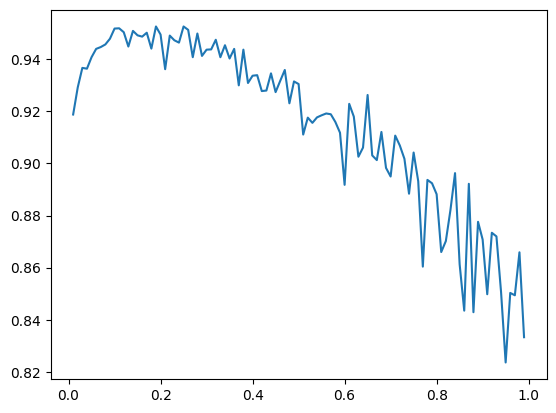